In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import os
import math 
import cv2
import re
from tqdm import tqdm

sns.set_style('dark')

# Face Recognition

<div class='alert alert-info'>A <strong>facial recognition system</strong> is a technology capable of matching a human face from a digital image or a video frame against a database of faces. Such a system is typically employed to authenticate users through ID verification services, and works by pinpointing and measuring facial features from a given image.</div>

<img src='https://www.thalesgroup.com/sites/default/files/database/assets/images/2020-07/gov-facial-recognition-in-action.jpg'>

In [5]:
data = pd.read_csv("/kaggle/input/celeba-face-recognition-triplets/CelebA FR Triplets/CelebA FR Triplets/triplets.csv")
data = data.sample(frac=1).reset_index(drop=True)

In [6]:
data

,anchor,id1,pos,id2,neg,id3
0,088256.jpg,7372,064693.jpg,7372,051371.jpg,794
1,120477.jpg,3006,013729.jpg,3006,105202.jpg,1135
2,103575.jpg,7572,064147.jpg,7572,060537.jpg,8879
3,134573.jpg,4322,071202.jpg,4322,059031.jpg,3554
4,147321.jpg,1774,137991.jpg,1774,174139.jpg,3642
...,...,...,...,...,...,...
16327,185914.jpg,8351,191636.jpg,8351,071789.jpg,2368
16328,137539.jpg,4240,148509.jpg,4240,177506.jpg,3224
16329,114376.jpg,9826,109217.jpg,9826,013670.jpg,5365
16330,102243.jpg,2881,011661.jpg,2881,178667.jpg,577


# Typical Tasks in Face Recognition
- Generally Speaking, a facial recognition system can be used to accomplish two kinds of tasks
    - **Face Verification:** One-to-one match that compares a query face image against a template face image whose identity is being claimed.
    - **Face Identification:** One-to-many matches that compare a query face image against all the template images in the database to determine the identity of the query face.
    
<img src='https://drek4537l1klr.cloudfront.net/elgendy/v-8/Figures/10_img_0003.png'>

In [7]:
base = '/kaggle/input/celeba-face-recognition-triplets/CelebA FR Triplets/images'

In [8]:
train = data.head(14332)
test = data.tail(2000)

In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense, Input, Layer, Lambda, BatchNormalization 
from tensorflow.keras.applications import ResNet50, VGG16, InceptionV3, MobileNetV2, EfficientNetB3
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# One Shot Learning

- One-shot learning is a classification task where one, or a few, examples are used to classify many new examples in the future.
- This characterizes tasks seen in the field of face recognition, such as face identification and face verification, where people must be classified correctly with different facial expressions, lighting conditions, accessories, and hairstyles given one or a few template photos.
- Modern face recognition systems approach the problem of one-shot learning via face recognition by learning a rich low-dimensional feature representation, called a face embedding, that can be calculated for faces easily and compared for verification and identification tasks.
- For our Face Recognition task we are going to produce vector embeddings of size **128** (FaceNet)

<div class='alert alert-info'><strong>FaceNet</strong> which is a one shot learning model training for face recognition takes a person's face and compresses it into a vector of 128 numbers. Ideally, embeddings of similar faces are also similar.</div>

<img src='https://www.researchgate.net/publication/345971024/figure/fig4/AS:958699908636682@1605583278305/Demonstration-of-One-Shot-Learning-technique.ppm'>

In [10]:
embeddings = tf.keras.models.load_model("/kaggle/input/facenet/keras-facenet/model/facenet_keras.h5")
embeddings.load_weights('/kaggle/input/facenet/keras-facenet/weights/facenet_keras_weights.h5')

In [11]:
embeddings.summary()

Model: "inception_resnet_v1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 160, 160, 3) 0                                            
__________________________________________________________________________________________________
Conv2d_1a_3x3 (Conv2D)          (None, 79, 79, 32)   864         input_1[0][0]                    
__________________________________________________________________________________________________
Conv2d_1a_3x3_BatchNorm (BatchN (None, 79, 79, 32)   96          Conv2d_1a_3x3[0][0]              
__________________________________________________________________________________________________
Conv2d_1a_3x3_Activation (Activ (None, 79, 79, 32)   0           Conv2d_1a_3x3_BatchNorm[0][0]    
________________________________________________________________________________

# Siamese Network for Face Recognition
- A Siamese neural network is an artificial neural network that uses the same weights while working in tandem on two different input vectors to compute comparable output vectors.
- Siamese Networks can be applied to different use cases, like detecting duplicates, finding anomalies, and face recognition.
- There are different ways to train a siamese network, but we will go with the triplet loss function
- **Triplet loss** is a loss function for machine learning algorithms where a reference input (called anchor) is compared to a matching input (called positive) and a non-matching input (called negative).

<img src='https://omoindrot.github.io/assets/triplet_loss/triplet_loss.png'>

In [12]:
img_size = 160

for layer in embeddings.layers: 
    if layer.name == 'Block8_3_ScaleSum':
        break
    layer.trainable = False
    
image_input1 = Input(shape=(img_size,img_size,3),name='Image1')
image_input2 = Input(shape=(img_size,img_size,3),name='Image2')
image_input3 = Input(shape=(img_size,img_size,3),name='Image3')

anchor = embeddings(image_input1)
positive = embeddings(image_input2)
negative = embeddings(image_input3)

siamese_network = Model(inputs=[image_input1,image_input2,image_input3], outputs=[anchor,positive,negative])
siamese_network.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
Image1 (InputLayer)             [(None, 160, 160, 3) 0                                            
__________________________________________________________________________________________________
Image2 (InputLayer)             [(None, 160, 160, 3) 0                                            
__________________________________________________________________________________________________
Image3 (InputLayer)             [(None, 160, 160, 3) 0                                            
__________________________________________________________________________________________________
inception_resnet_v1 (Functional (None, 128)          22808144    Image1[0][0]                     
                                                                 Image2[0][0]                 

# Triplet Generation
- We generate triplets to train our model 
1. **Anchor:** An input image
2. **Positive:** Same image as the identity in the input image
3. **Negative:** Different image than the identity in the input image

<img src='https://qdrant.tech/articles_data/triplet-loss/loss_objective.png'>

In [13]:
batch_size = 32
datagen = ImageDataGenerator(rescale=1/255.)

In [14]:
class TripleGenerator(tf.keras.utils.Sequence):
    
    def __init__(self, gen1, gen2, gen3):
        
        self.gen1 = gen1
        self.gen2 = gen2
        self.gen3 = gen3

    def __len__(self):
        
        return len(self.gen1)

    def __getitem__(self, i):
        
        x1 = self.gen1[i]
        x2 = self.gen2[i]
        x3 = self.gen3[i]
        
        return [x1,x2,x3]

In [17]:
directory = '/kaggle/input/celeba-face-recognition-triplets/CelebA FR Triplets/CelebA FR Triplets/images'

def create_generator(folder,dataset,column):
    generator = datagen.flow_from_dataframe(dataframe=dataset,
                                            directory=folder,
                                            x_col=column,
                                            target_size=(img_size, img_size),
                                            batch_size=batch_size,
                                            class_mode=None,
                                            shuffle=False)
    return generator

train_generator1 = create_generator(directory,train,'anchor')
train_generator2 = create_generator(directory,train,'pos')
train_generator3 = create_generator(directory,train,'neg')

test_generator1 = create_generator(directory,test,'anchor')
test_generator2 = create_generator(directory,test,'pos')
test_generator3 = create_generator(directory,test,'neg')

train_generator = TripleGenerator(train_generator1,train_generator2,train_generator3)
test_generator = TripleGenerator(test_generator1,test_generator2,test_generator3)

Found 14332 validated image filenames.
Found 14332 validated image filenames.
Found 14332 validated image filenames.
Found 2000 validated image filenames.
Found 2000 validated image filenames.
Found 2000 validated image filenames.


In [18]:
samples = train_generator[0]

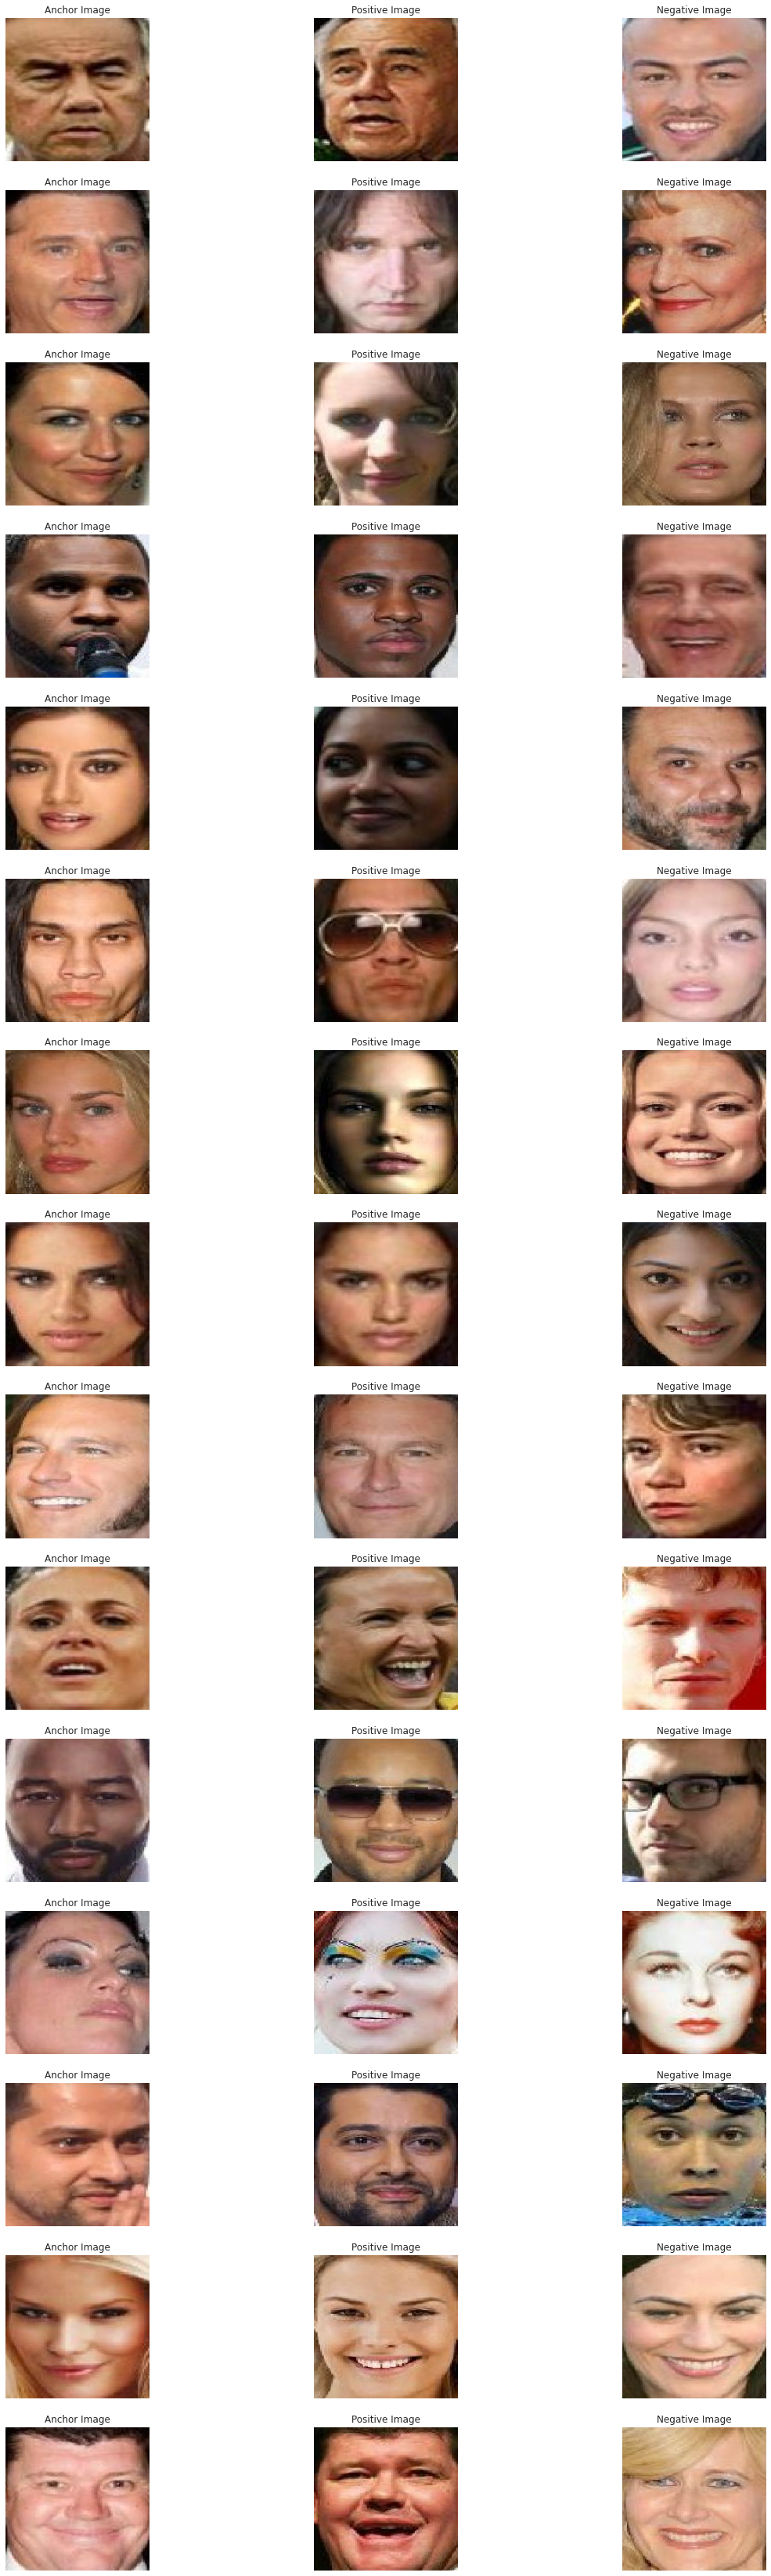

In [19]:
f, axarr = plt.subplots(15,3,figsize=(20, 60))

for i in range(0,15):

    axarr[i,0].imshow(samples[0][i])
    axarr[i,0].title.set_text('Anchor Image')
    axarr[i,0].axis('off')
    axarr[i,1].imshow(samples[1][i])
    axarr[i,1].title.set_text('Positive Image')
    axarr[i,1].axis('off')
    axarr[i,2].imshow(samples[2][i])
    axarr[i,2].title.set_text('Negative Image')
    axarr[i,2].axis('off')

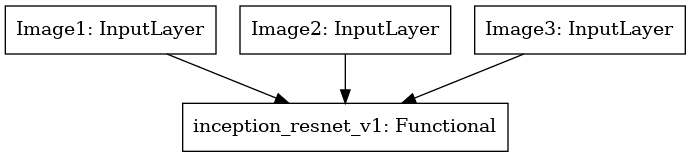

In [20]:
tf.keras.utils.plot_model(
    siamese_network,
    to_file='model.png')

In [21]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [23]:
model_path = "model.h5"
checkpoint = ModelCheckpoint(model_path,
                             monitor="val_loss",
                             mode="min",
                             save_best_only = True,
                             verbose=1,
                             save_weights_only=True)

earlystop = EarlyStopping(monitor = 'val_loss', 
                          min_delta = 0, 
                          patience = 5,
                          verbose = 1,
                          restore_best_weights = True)

learning_rate_reduction = ReduceLROnPlateau(monitor='val_loss', 
                                            patience=4, 
                                            verbose=1, 
                                            factor=0.3, 
                                            min_lr=0.00000001)

# Custom Model: Model Subclassing
- Since we are going to use custom inputs/outputs and a custom loss, it is a good idea to use model subclassing to define the custom features of our model
- **Loss Function:** Triplet Loss

<img src='https://blog.kakaocdn.net/dn/bh8XAu/btqw87frvWo/vcGVikKxlm1r0XTo3gKo80/img.png'>

In [24]:
from tensorflow.keras import losses
from tensorflow.keras import optimizers
from tensorflow.keras import metrics

In [25]:
class SiameseModel(Model):
    
    def __init__(self, siamese_network, margin=0.5):
        super().__init__()
        self.siamese_network = siamese_network
        self.margin = margin
        self.loss_tracker = metrics.Mean(name='loss')
        
    def call(self, inputs):
        return self.siamese_network(inputs)
    
    def train_step(self, data):
        with tf.GradientTape() as tape:
            loss = self._compute_loss(data)
        gradients = tape.gradient(loss,self.siamese_network.trainable_weights)
        self.optimizer.apply_gradients(
                    zip(gradients,self.siamese_network.trainable_weights)
        )
        
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}
    
    def test_step(self, data):
        loss = self._compute_loss(data)
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}
    
    def _compute_loss(self, data):
        anchor, positive, negative = self.siamese_network(data)
        pos_dist = tf.reduce_sum(tf.square(anchor-positive), -1)
        neg_dist = tf.reduce_sum(tf.square(anchor-negative), -1)
        loss = pos_dist - neg_dist + self.margin
        loss = tf.maximum(loss, 0.0)
        return loss 
    
    @property
    def metrics(self):
        return [self.loss_tracker]

In [26]:
siamese_model = SiameseModel(siamese_network)
siamese_model.compile(optimizer=optimizers.Adam(learning_rate=0.0001))

In [27]:
from sklearn.metrics.pairwise import euclidean_distances as L2

# Model Training

<div class='alert alert-warning'><strong>Note:</strong> Please note that this model is <strong>bound to overfit</strong> as we have very less number of triplets to train on (16000+). For tasks like Face Recognition it is a good idea to have large and diverse amount of triplet images. Since our objective is to only demonstrate the training of a siamese network for face recogniton we will finetune the model and use the best validation loss checkpointed model for inference (to avoid using the overfitted model)</div>

In [28]:
try:
    history = siamese_model.fit(train_generator, validation_data=test_generator,
                            epochs=50,callbacks=[checkpoint,earlystop,learning_rate_reduction]) 
except KeyboardInterrupt:
    print("\nTraining Stopped!")

Epoch 1/50
448/448 [==============================] - 417s 901ms/step - loss: 0.0945 - val_loss: 0.0412

Epoch 00001: val_loss improved from inf to 0.04119, saving model to model.h5
Epoch 2/50
448/448 [==============================] - 99s 221ms/step - loss: 0.0203 - val_loss: 0.0335

Epoch 00002: val_loss improved from 0.04119 to 0.03349, saving model to model.h5
Epoch 3/50
448/448 [==============================] - 98s 219ms/step - loss: 0.0105 - val_loss: 0.0397

Epoch 00003: val_loss did not improve from 0.03349
Epoch 4/50
448/448 [==============================] - 98s 218ms/step - loss: 0.0063 - val_loss: 0.0428

Epoch 00004: val_loss did not improve from 0.03349
Epoch 5/50
448/448 [==============================] - 102s 228ms/step - loss: 0.0053 - val_loss: 0.0532

Epoch 00005: val_loss did not improve from 0.03349
Epoch 6/50
448/448 [==============================] - 100s 222ms/step - loss: 0.0045 - val_loss: 0.0437

Epoch 00006: val_loss did not improve from 0.03349

Epoch 0000

In [29]:
siamese_network.load_weights("model.h5")

In [30]:
y_pred = siamese_network.predict(test_generator)

In [31]:
from sklearn.metrics.pairwise import euclidean_distances as L2, cosine_similarity as cs

# Inference
- Lets calculate the L2 distance between all the anchor-positive and anchor-negative images
- We will then perform a statistical analysis to identify the ideal threshold to be used for the verification and identification tasks

In [32]:
test

,anchor,id1,pos,id2,neg,id3
14332,005461.jpg,407,143314.jpg,407,158929.jpg,9597
14333,130210.jpg,6597,074618.jpg,6597,197953.jpg,6411
14334,147135.jpg,7330,040188.jpg,7330,103444.jpg,3623
14335,022595.jpg,5125,012099.jpg,5125,098502.jpg,4385
14336,013170.jpg,2753,008930.jpg,2753,073202.jpg,1977
...,...,...,...,...,...,...
16327,185914.jpg,8351,191636.jpg,8351,071789.jpg,2368
16328,137539.jpg,4240,148509.jpg,4240,177506.jpg,3224
16329,114376.jpg,9826,109217.jpg,9826,013670.jpg,5365
16330,102243.jpg,2881,011661.jpg,2881,178667.jpg,577


In [33]:
distances = []
for i in range(len(test)):
    pos = L2(y_pred[0][i,:].reshape(1,-1),y_pred[1][i,:].reshape(1,-1))[0][0]
    neg = L2(y_pred[0][i,:].reshape(1,-1),y_pred[2][i,:].reshape(1,-1))[0][0]
    distances.append([pos,neg])

In [34]:
test.loc[:,['pos_dist','neg_dist']] = distances

/opt/conda/lib/python3.7/site-packages/pandas/core/indexing.py:1835: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value[:, i].tolist(), pi)


In [35]:
test

,anchor,id1,pos,id2,neg,id3,pos_dist,neg_dist
14332,005461.jpg,407,143314.jpg,407,158929.jpg,9597,2.018481,2.754751
14333,130210.jpg,6597,074618.jpg,6597,197953.jpg,6411,1.979632,2.678779
14334,147135.jpg,7330,040188.jpg,7330,103444.jpg,3623,1.177459,2.546958
14335,022595.jpg,5125,012099.jpg,5125,098502.jpg,4385,1.396271,2.387618
14336,013170.jpg,2753,008930.jpg,2753,073202.jpg,1977,1.775021,1.955308
...,...,...,...,...,...,...,...,...
16327,185914.jpg,8351,191636.jpg,8351,071789.jpg,2368,1.601029,1.635344
16328,137539.jpg,4240,148509.jpg,4240,177506.jpg,3224,1.287220,2.117000
16329,114376.jpg,9826,109217.jpg,9826,013670.jpg,5365,1.213724,2.797061
16330,102243.jpg,2881,011661.jpg,2881,178667.jpg,577,1.130934,2.000386


## Descriptive Stats: Anchor-Postive Distance and Anchor-Negative Distance
- Lets analyze the IQR plots of distances

In [36]:
test.describe()

,id1,id2,id3,pos_dist,neg_dist
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,5059.623500,5059.623500,4875.986500,1.440199,2.415510
std,2904.057115,2904.057115,2919.616824,0.314533,0.361267
min,3.000000,3.000000,1.000000,0.373167,1.408461
25%,2572.000000,2572.000000,2264.750000,1.220085,2.147226
50%,5098.000000,5098.000000,4876.500000,1.411038,2.426209
75%,7491.500000,7491.500000,7410.000000,1.627478,2.670647
max,10167.000000,10167.000000,10162.000000,2.941375,3.396578


## Threshold Decision
- By looking at the descriptive stats and the IQR Box plots, trying out values between 1.5-2.0 for threshold will make sense

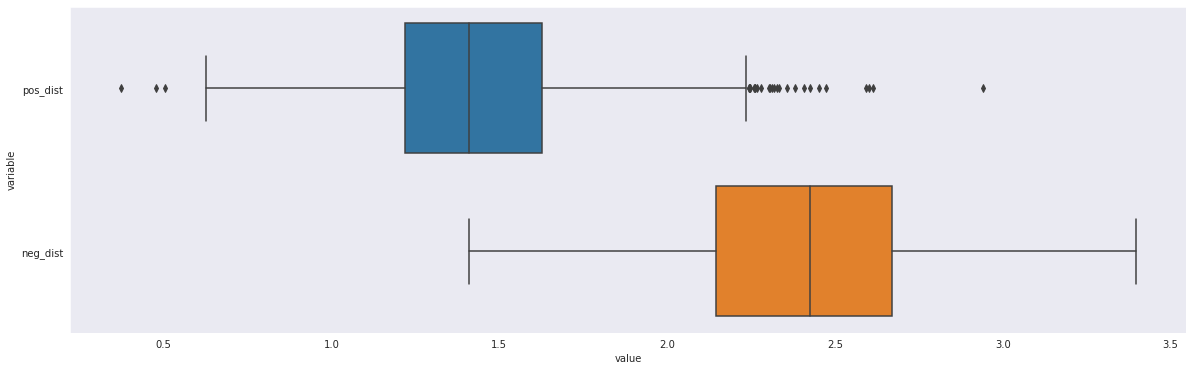

In [37]:
plt.figure(figsize=(20,6))
sns.boxplot(x="value", y="variable", data=pd.melt(test[['pos_dist','neg_dist']]))
plt.rc('font', size=20)
plt.show()

### Threshold of 1.65 gives correct decisions 83.55% of the time, so let's go with that. You can try out different values as well.

In [38]:
len(test[(test['pos_dist']<1.65) & (test['neg_dist']>1.65)])/len(test)

0.763

# Extraction of Embeddings Model from Siamese Network
- Since we don't want to use the three input-three output siamese model every time we are required to create embeddings, we will extract the embeddings network from the model and use it to create embeddings for our future tasks

In [39]:
siamese_network.layers

In [41]:
face_embeddings = siamese_network.layers[-1]

In [ ]:
!pip install mtcnn

# Inference Pipeline for Face Recognition Systems
- For detection of faces we will use MTCNN
- For the alignment, to maintain the simplicity of the scope of this kernel we will only use 2D alignment
- We will then use our model to extract the features

<img src='https://www.researchgate.net/publication/282863610/figure/fig1/AS:669508570214408@1536634690438/Processing-pipeline-of-face-recognition.jpg'>